<a href="https://colab.research.google.com/github/junggeyy/gis-notebooks/blob/main/site_suitability_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Site Suitability Analysis

This notebook will contain a phase by phase breakdown and process of a site suitability analysis project, for a Fire Station, in Kathmandu Metropolitan City.

### Problem Definition and Criteria Selection


In [ ]:
%pip install rioxarray xarray-spatial

In [2]:
import geopandas as gpd
import os
import rasterio
import rioxarray
import matplotlib.pyplot as plt

### Data Acqusition

In [47]:
data_path = '/content/drive/MyDrive/project_srcs/site-suitability-analysis/data'

boundary_file = 'nepal-municipalities.geojson'
roads_file = 'kmc-drivable-roads.geojson'
dem_file = 'ktm-dem.tif'
landuse_file = 'ktm-landuse.geojson'
firestation_file = 'ktm-fire-stations.geojson'

boundary_path = os.path.join(data_path, boundary_file)
roads_path = os.path.join(data_path, roads_file)
dem_path = os.path.join(data_path, dem_file)
landuse_path = os.path.join(data_path, landuse_file)
firestation_path = os.path.join(data_path, firestation_file)

In [49]:
ktm_firestation = gpd.read_file(firestation_path)
ktm_firestation

,id,@id,amenity,building,name:en,geometry
0,way/211751501,way/211751501,fire_station,yes,None,"POLYGON ((85.36095 27.69615, 85.36091 27.69608..."
1,node/9722113225,node/9722113225,fire_station,None,Mahanagar Fire Briged and Training Center,POINT (85.36554 27.73176)


In [48]:
ktm_landuse = gpd.read_file(landuse_path)
ktm_landuse

,id,@id,access,addr:city,addr:street,addr:tole,addr:ward,area,barrier,building:part,...,roof:orientation,roof:type,source,sport,surface,type,water,wikidata,wikipedia,geometry
0,relation/4572868,relation/4572868,None,None,None,None,None,None,None,None,...,None,None,None,None,None,multipolygon,None,None,None,"POLYGON ((85.35649 27.70081, 85.35645 27.70081..."
1,relation/13833096,relation/13833096,None,None,None,None,None,None,None,None,...,None,None,None,None,None,multipolygon,None,None,None,"MULTIPOLYGON (((85.35509 27.69919, 85.35509 27..."
2,relation/14959438,relation/14959438,None,None,None,None,None,None,None,None,...,None,None,None,None,None,multipolygon,None,None,None,"POLYGON ((85.32042 27.70852, 85.32036 27.7085,..."
3,way/178257646,way/178257646,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.3487 27.68696, 85.34849 27.68691,..."
4,way/180082361,way/180082361,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.343 27.72946, 85.34292 27.72928, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,way/1395933784,way/1395933784,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.32273 27.7344, 85.32356 27.73507,..."
315,way/1395960632,way/1395960632,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.31426 27.707, 85.31425 27.70691, ..."
316,way/1396136699,way/1396136699,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.32211 27.73468, 85.32215 27.73469..."
317,way/1413019789,way/1413019789,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.32934 27.70579, 85.32931 27.70578..."


In [4]:
nepal_boundary = gpd.read_file(boundary_path)
nepal_boundary.head()

,id,F_ID,N_ID,NAME,LEVEL,DISTRICT,geometry
0,None,104,bhaktapur-bhaktapur,Bhaktapur,Nagarpalika,Bhaktapur,"POLYGON ((85.44459 27.66441, 85.44378 27.66359..."
1,None,105,madhyapur -thimi-bhaktap,Madhyapur Thimi,Nagarpalika,Bhaktapur,"POLYGON ((85.36314 27.66892, 85.35419 27.66769..."
2,None,343,kathmandu-kathmandu,Kathmandu,Mahanagarpalika,Kathmandu,"POLYGON ((85.28577 27.68983, 85.28414 27.6927,..."
3,None,344,kirtipur-kathmandu,Kirtipur,Nagarpalika,Kathmandu,"POLYGON ((85.25319 27.64555, 85.25238 27.65416..."
4,None,396,chitwan -national -park-,Chitwan National Park,national-park,Makwanpur,"POLYGON ((84.71727 27.56355, 84.71727 27.55945..."


In [5]:
nepal_boundary = nepal_boundary.set_index('N_ID')
ktm_boundary = nepal_boundary.loc[['kathmandu-kathmandu']]
ktm_boundary

,id,F_ID,NAME,LEVEL,DISTRICT,geometry
N_ID,,,,,,
kathmandu-kathmandu,None,343,Kathmandu,Mahanagarpalika,Kathmandu,"POLYGON ((85.28577 27.68983, 85.28414 27.6927,..."


<Axes: >

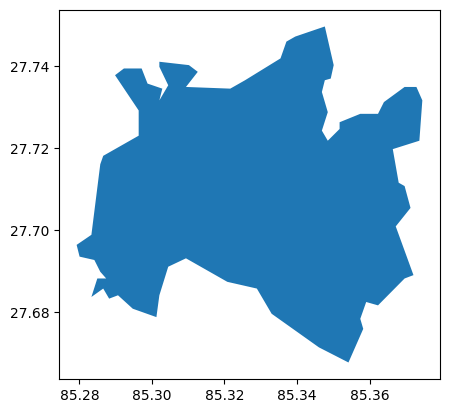

In [6]:
ktm_boundary.plot()

In [7]:
ktm_roads = gpd.read_file(roads_path)
ktm_roads.head()

,id,@id,FIXME,Household Code,Household Info By,access,addr:city,addr:place,addr:street,alt,...,trail_visibility,tunnel,type,vehicle,watch:80n,wheelchair,width,wikidata,wikipedia,geometry
0,way/220295107,way/220295107,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.31182 27.70238, 85.31181 27.70232..."
1,way/500866244,way/500866244,None,None,None,service,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.32289 27.69548, 85.32291 27.69555..."
2,way/1034447021,way/1034447021,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.35233 27.70185, 85.35233 27.70186..."
3,way/1174359027,way/1174359027,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.33708 27.68847, 85.33712 27.68847..."
4,way/1174944596,way/1174944596,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,"POLYGON ((85.33618 27.68923, 85.33628 27.68984..."


In [8]:
ktm_roads = ktm_roads[['@id', 'name', 'surface', 'smoothness', 'lanes', 'maxspeed', 'access', 'geometry']]

In [9]:
dem = rasterio.open(dem_path)

In [10]:
ktm_dem = rioxarray.open_rasterio(dem)

### Data Preprocessing

In [11]:
print("Current CRS:")
print(ktm_roads.crs)
print(ktm_boundary.crs)
print(ktm_dem.rio.crs)

ktm_roads = ktm_roads.to_crs('ESRI:102306')
ktm_boundary = ktm_boundary.to_crs('ESRI:102306')
ktm_dem = ktm_dem.rio.reproject("ESRI:102306")

print("\nAfter projection:")
print(ktm_roads.crs)
print(ktm_boundary.crs)
print(ktm_dem.rio.crs)

Current CRS:
EPSG:4326
EPSG:4326
EPSG:4326

After projection:
ESRI:102306
ESRI:102306
ESRI:102306


In [12]:
ktm_road_clipped = ktm_roads.clip(mask=ktm_boundary)
ktm_dem_clipped = ktm_dem.rio.clip(ktm_boundary.geometry)

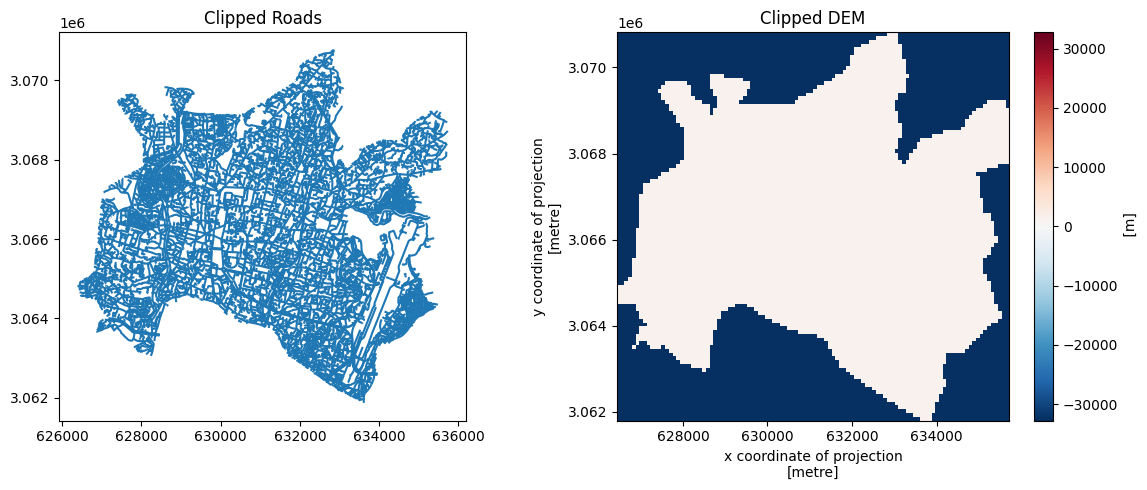

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ktm_road_clipped.plot(ax=ax[0])
ax[0].set_title("Clipped Roads")

ktm_dem_clipped.plot(ax=ax[1])
ax[1].set_title("Clipped DEM")

plt.tight_layout()
plt.show()

### Transformation and Standarization

#### Terrain Transformation

The pixels in `ktm_dem_clipped` raster currently provides the absolute height of land, but we need to identify slopes to find an ideal place of our site.

So, we first calculate the gradient to get the maximum rate of elevation change between each pixel and its neighbors in the `ktm_dem_clipped` raster. This provides us with a new raster where the pixel values represent the slope in degrees.

In [14]:
# squeezing the ktm_dem_clipped data to be 2D for the xrspatial.slope function
# this removes the single dimension entry, band, which isn't needed for slope operation
ktm_dem_clipped_2d = ktm_dem_clipped.squeeze()

In [15]:
from xrspatial import slope

slope_agg = slope(ktm_dem_clipped_2d, name='slope', method='planar')
slope_agg.values

Now, we normalize the raw slope degree values to a suitability score of 1 to 5 so that we will have a similar data structure + type to work with.

In [17]:
import numpy as np
import xarray as xr

In [19]:
classified_slope = xr.zeros_like(slope_agg)

# min value, max value, score
slope_rules = [ (-1, 3, 5),
                (3, 7, 4),
                (7, 12, 3),
                (12, 20, 2),
                (20, 90, 1)
              ]

for min_value, max_value, score in slope_rules:
  mask = (slope_agg > min_value) & (slope_agg <= max_value)
  classified_slope = xr.where(mask, score, classified_slope) # numpy -> classified_slope[mask] = score

# setting back nan(s)
classified_slope = xr.where(np.isnan(slope_agg), np.nan, classified_slope)

In [20]:
print(np.unique(classified_slope))

[ 1.  2.  3.  4.  5. nan]


#### Proximity Transformation

Here, we convert our `ktm_roads` vector into a raster, by rasterization, so that both our road & dem data are mathematically compatible.

In [21]:
from rasterio.features import rasterize

out_shape = ktm_dem_clipped_2d.rio.shape
transform = ktm_dem_clipped_2d.rio.transform()

shapes = [(geom, 1) for geom in ktm_road_clipped.geometry]

burned_road_raster = rasterize(shapes, out_shape=out_shape,
                               transform=transform, fill=0, all_touched=True)


In [22]:
from xrspatial import proximity

raster = xr.DataArray(burned_road_raster, coords=ktm_dem_clipped_2d.coords, dims=ktm_dem_clipped_2d.dims)

distance_agg = proximity(raster)

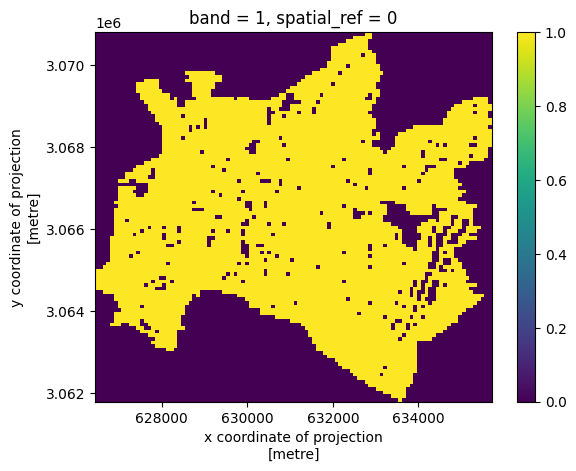

In [23]:
raster.plot()

In [24]:
classified_proximity = xr.zeros_like(distance_agg)

# mininmum distance, maximum distance, score
proximity_rules = [ (-1, 100, 5),
                    (100, 300, 4),
                    (300, 500, 3),
                    (500, 800, 2),
                    (800, 9999, 1)
                  ]

for min_value, max_value, score in proximity_rules:
  mask = (distance_agg > min_value) & (distance_agg <= max_value)
  classified_proximity = xr.where(mask, score, classified_proximity)

# since the rasterizing process overwrote nans to be 0s, we set back the nan values,
# representing outside city boundary, using the slope_agg matrix
classified_proximity = xr.where(np.isnan(slope_agg), np.nan, classified_proximity)

In [25]:
print(np.unique(classified_proximity))

[ 1.  2.  3.  4.  5. nan]


### Overlay Analysis and Selection

In [26]:
# weighted linear combinaton
W_slope = 0.4
W_proximity = 0.6

suitability = (W_slope * classified_slope) + (W_proximity * classified_proximity)

In [27]:
threshold = 4.5

suitability = xr.where(suitability >= threshold, suitability, np.nan)

In [42]:
from rasterio.features import shapes
from shapely.geometry import shape

vectors = shapes(suitability.values, transform=suitability.rio.transform())

# at this point, 'vectors' is a generator object which we have to consume
feature_list = []
for geom, value in vectors:
  if not np.isnan(value):
    feature_list.append({
        "geometry": shape(geom),
        "suitability_score": value
    })

# converting the sites list into GDF
final_sites_gdf = gpd.GeoDataFrame(feature_list, crs="ESRI:102306")


In [43]:
final_sites_gdf.head()

,geometry,suitability_score
0,"POLYGON ((632916.206 3070726.463, 632916.206 3...",4.6
1,"POLYGON ((631866.199 3070463.961, 631866.199 3...",5.0
2,"POLYGON ((632653.704 3070463.961, 632653.704 3...",4.6
3,"POLYGON ((633003.706 3070288.96, 633003.706 30...",4.6
4,"POLYGON ((632653.704 3070638.962, 632653.704 3...",4.6


In [44]:
# filtering the sites gdf to only include areas above or equal to 4000 square meters
# then, sorting it on basis on suitability score & area, highest to lowest
final_sites_gdf['area'] = final_sites_gdf.geometry.area
final_sites_gdf = final_sites_gdf[final_sites_gdf['area'] >= 4000]

final_sites_gdf = final_sites_gdf.sort_values(
    by=['suitability_score', 'area'], ascending=[False, False]).reset_index(drop=True)

final_sites_gdf.head()

,geometry,suitability_score,area
0,"POLYGON ((632478.703 3070551.462, 632478.703 3...",5.0,2.712642e+07
1,"POLYGON ((634928.718 3064863.927, 634928.718 3...",5.0,2.679720e+06
2,"POLYGON ((634753.717 3066351.436, 634753.717 3...",5.0,1.225015e+06
3,"POLYGON ((626791.168 3064863.927, 626791.168 3...",5.0,2.756284e+05
4,"POLYGON ((632916.206 3070288.96, 632916.206 30...",5.0,1.148451e+05


In [45]:
final_sites_gdf.explore()